In [1]:
homedir = '../'

In [2]:
# Standard library
import os

# Scientific computing and linear algebra
import numpy as np
import scipy.linalg as sl

# libstempo library
import libstempo as LT
import libstempo.toasim as LTsim
from libstempo.toasim import (
    add_efac, 
    add_equad, 
    add_gwb, 
    add_cgw
)

# enterprise and extensions
from enterprise.pulsar import Pulsar
from enterprise.signals.utils import powerlaw, createfourierdesignmatrix_dm
from enterprise.signals import white_signals, gp_signals, parameter
from enterprise.signals.signal_base import PTA
from enterprise_extensions.sampler import JumpProposal

# PTMCMCSampler
from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc

# Plotting libraries
import matplotlib.pyplot as plt
import corner

# Import pickle
import pickle

/home/llaett/projects/thesis/master-thesis-code/.venv/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename
PINT not installed. PINT or libstempo are required to use par and tim files.


Optional mpi4py package is not installed.  MPI support is not available.


In [3]:
# Modified Julian Date to Gregorian Date
def mjd2gd(mjd):
    return 2000 + (mjd - 51544.5) / 365.25

In [4]:
# Constants
DAY = 24 * 3600
YEAR = 365.25 * DAY

def add_efac(psr, efac=1.0, flagid=None, flags=None, seed=None):
    """
    Adapted from libstempo.
    Add nominal TOA errors, multiplied by the `efac` factor.
    Optionally, use a pseudorandom-number-generator seed.
    """
    if seed is not None:
        np.random.seed(seed)

    # Default efacvec
    efacvec = np.ones(psr.nobs)

    if flags is None:
        if not np.isscalar(efac):
            raise ValueError("If flags is None, efac must be a scalar.")
        efacvec = np.full(psr.nobs, efac)
    elif flagid is not None and not np.isscalar(efac):
        if len(efac) == len(flags):
            flagvals = np.array(psr.flagvals(flagid))
            for ct, flag in enumerate(flags):
                efacvec[flagvals == flag] = efac[ct]

    # Add TOA errors with random noise
    psr.stoas[:] += efacvec * psr.toaerrs * (1e-6 / DAY) * np.random.randn(psr.nobs)

def add_time_corr_signal(psr, A, gamma, components=10, tspan=None, seed=None, idx=0, factor=1.0):
    """
    Taken from libstempo.
    Add DM variations with P(f) = A^2 / (12 pi^2) (f year)^-gamma using Fourier bases.
    Optionally use a pseudorandom-number-generator seed.
    """
    if seed is not None:
        np.random.seed(seed)

    t = psr.toas()
    fref = 1400
    v = (fref / psr.freqs) ** idx

    minx, maxx = np.min(t), np.max(t)
    if tspan is None:
        x = (t - minx) / (maxx - minx)
        T = (DAY / YEAR) * (maxx - minx)
    else:
        x = (t - minx) / tspan
        T = (DAY / YEAR) * tspan

    size = 2 * components
    F = np.zeros((psr.nobs, size))
    f = np.zeros(size)

    # Vectorized computation of Fourier components
    i_vals = np.arange(1, components + 1)
    i_vals = i_vals[:, np.newaxis]  # Shape (30, 1)
    x = np.asarray(x)  # Ensure x is a 1D array
    F[:, ::2] = np.cos(2 * np.pi * i_vals * x).T  # Cosine terms
    F[:, 1::2] = np.sin(2 * np.pi * i_vals * x).T  # Sine terms

    f[::2] = f[1::2] = np.squeeze(i_vals / T)

    norm = A**2 * YEAR**2 / (12 * np.pi**2 * T)
    prior = norm * f ** (-gamma)

    y = np.sqrt(prior) * np.random.randn(size)
    psr.stoas[:] += (1.0 / DAY) * np.dot(F, y) * v * factor


In [5]:
psrname = "J1909-3744"
parfile = f"../data/DR2new/%s/%s.par"%(psrname, psrname)   #load time file
timfile = f"../data/DR2new/%s/%s_all.tim"%(psrname, psrname)   #load model parameter
ltpsr = LT.tempopulsar(parfile, timfile) 
tgd = mjd2gd(ltpsr.toas())  #xaxis

## Create model with enterprise

Create Enteprise pulsar object from libstempo pulsar object 

In [6]:
psr = Pulsar(ltpsr)

### Compose the model including each submodel

Each sub-model will be included one by one in the following cells.
If a model includes parameters, they are first defined with their prior ranges.

#### Include Timing Model (TM) param errors (marginalized)
The TM is included as a Guassian Process (GP). We will marginalized over its parameters.

In [7]:
s = gp_signals.TimingModel()

#### Include white noise EFAC

In [8]:
efac_prior = parameter.Uniform(0.1, 5)

s += white_signals.MeasurementNoise(efac=efac_prior)

#### Include Red noise
We define the spectrum as a power law: `powerlaw`)
The red noise is included as a gaussian process using a Fourier basis with a defined number of components (i.e. frequency bins): `gp_signals.FourierBasisGP(pl, components=30)`

In [9]:
log10_A_rn_prior = parameter.Uniform(-18, -10)
gamma_rn_prior = parameter.Uniform(0, 7)
pl = powerlaw(log10_A=log10_A_rn_prior, gamma=gamma_rn_prior)
s += gp_signals.FourierBasisGP(pl, components=30)

#### Include DM variations
THe spectrum is defined as a power law as for the red noise.
We use also a gaussian process but we define first the basis than we pass to the generic GP, `gp_signals.BasisGP`
This basis is a Fourier design matrix for DM.

In [10]:
log10_A_dm_prior = parameter.Uniform(-18, -10)
gamma_dm_prior = parameter.Uniform(0, 7)
pl = powerlaw(log10_A=log10_A_rn_prior, gamma=gamma_dm_prior) #tutorial had rn_prior
dm_basis = createfourierdesignmatrix_dm(nmodes=30)
s += gp_signals.BasisGP(pl, dm_basis, name="dm_gp")

### Create PTA object

Create PTA object from a list of models applied to pulsar. 
We will be able to compute likelihood and prior from this object

In [11]:
pta = PTA([s(psr)])

Print the parameters

In [12]:
for p in pta.param_names:
    print(p)

J1909-3744_dm_gp_gamma
J1909-3744_dm_gp_log10_A
J1909-3744_efac
J1909-3744_red_noise_gamma
J1909-3744_red_noise_log10_A


Compute the likelihood and prior for specific parameters

In [13]:
x = {
    f"{psrname}_dm_gp_gamma" : 3,
    f"{psrname}_dm_gp_log10_A" : -14,
    f"{psrname}_efac" : 1,
    f"{psrname}_red_noise_gamma" : 3,
    f"{psrname}_red_noise_log10_A" : -15
}
print(pta.get_lnlikelihood(x))
print(pta.get_lnprior(x))

30825.28102780701
-9.63993858658688


## Sampling 
### Set sampler

#### Create the sampler

We will use the sampler `PTMCMC` without the PT (Parallel Tempering) in practice so running on a single core. 

The number of samples is small for the purpose of the tutorial but increase it by at least a factor 10 if you want better results

In [14]:
# Define the output directory and create it if needed
outdir = "./../chains/sglpsr"
! mkdir -p {outdir}

# Number of sample
nsamples = 5e4

# Write the name of the parameters in the file pars.txt
with open(os.path.join(outdir, "pars.txt"), "w") as fout:
    for pname in pta.param_names:
        fout.write(pname + "\n")

# Define random starting value for the parameters and stack it in an array 
x0 = np.hstack([p.sample() for p in pta.params])

# Number of parameters
ndim = len(x0)

# Define the starting covariance matrix with only diagonal elements 
cov = np.diag(np.ones(ndim) * 0.01**2)

# Create the sampler 
sampler = ptmcmc(ndim, pta.get_lnlikelihood, pta.get_lnprior, cov, outDir=outdir)
## to resume black txt

#### Set the jump proposals

In [15]:
"""# Set Jump Proposals
jp = JumpProposal(pta, None, empirical_distr=None)

# always add draw from prior
sampler.addProposalToCycle(jp.draw_from_prior, 5)

# Select red_noise and DM for specific jump proposal 
sel_sig = {"red_noise":10, "dm":10}

# Jump proposals from priors of selected params
for s in sel_sig:
    if any([s in p for p in pta.param_names]):
        sampler.addProposalToCycle(jp.draw_from_par_prior(s), 10)"""

'# Set Jump Proposals\njp = JumpProposal(pta, None, empirical_distr=None)\n\n# always add draw from prior\nsampler.addProposalToCycle(jp.draw_from_prior, 5)\n\n# Select red_noise and DM for specific jump proposal \nsel_sig = {"red_noise":10, "dm":10}\n\n# Jump proposals from priors of selected params\nfor s in sel_sig:\n    if any([s in p for p in pta.param_names]):\n        sampler.addProposalToCycle(jp.draw_from_par_prior(s), 10)'

### Sample parameters

In [16]:
sampler.sample(x0, int(nsamples), SCAMweight=40, DEweight=60, AMweight=20)

Finished 2.00 percent in 11.883713 s Acceptance rate = 0.748

/home/llaett/projects/thesis/master-thesis-code/.venv/lib/python3.12/site-packages/enterprise/signals/parameter.py:70: RuntimeWarning: divide by zero encountered in log
  logpdf = np.log(self.prior(value, **kwargs))


Finished 20.00 percent in 155.326032 s Acceptance rate = 0.1891Adding DE jump with weight 60
Finished 100.00 percent in 673.223344 s Acceptance rate = 0.34167
Run Complete


### Analyse chain (i.e results of the sampling)

In [21]:
A_dm = 5e-14 ##from me
efac = 1. ##--
gamma_rn = 3 ##--
A_rn = 7e-14 ##--
gamma_dm=2.3 ##from me


# Load chain file
ch = np.loadtxt("%s/chain_1.txt"%outdir)

# Remove the burnin
ch = ch[int(len(ch)*.5):]
pars = np.loadtxt("%s/pars.txt"%outdir, dtype=str)
p_inj = [gamma_dm, np.log10(A_dm), efac, gamma_rn, np.log10(A_rn)]

In [22]:
for p in pars:
    print(p)

J1909-3744_dm_gp_gamma
J1909-3744_dm_gp_log10_A
J1909-3744_efac
J1909-3744_red_noise_gamma
J1909-3744_red_noise_log10_A


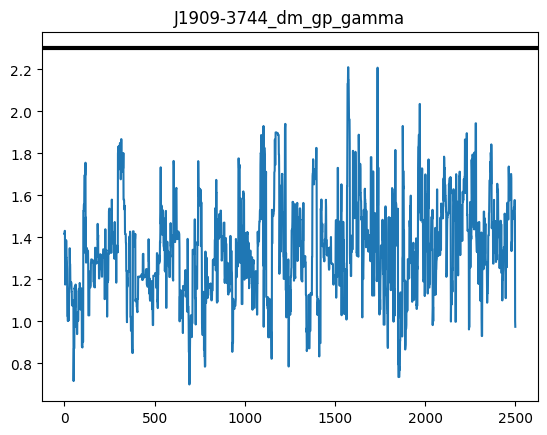

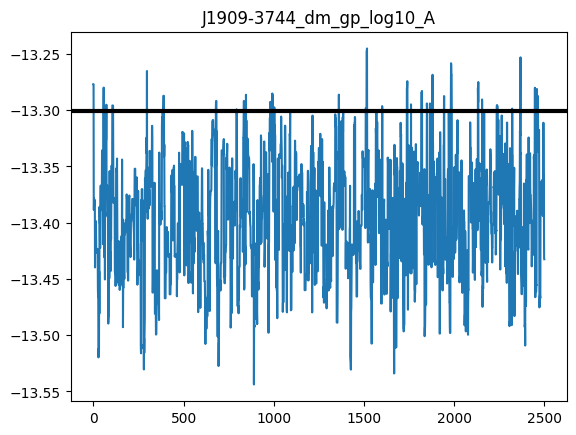

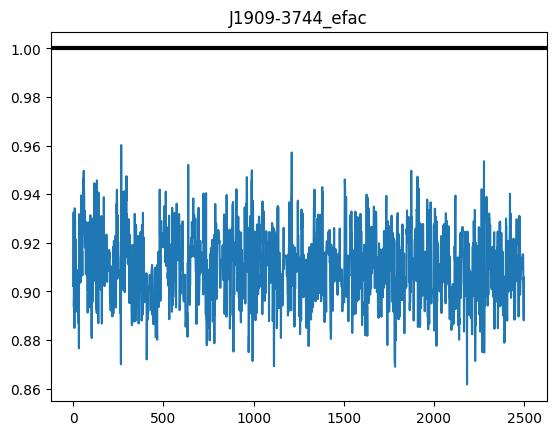

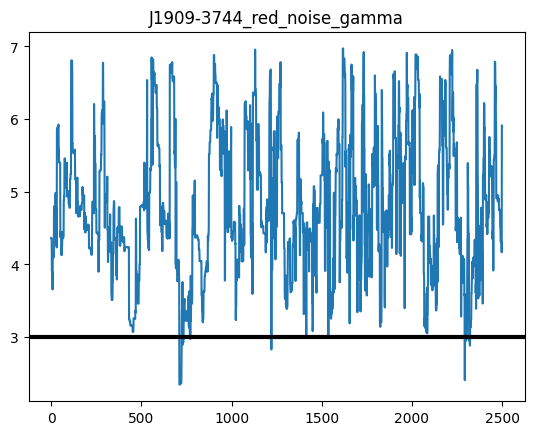

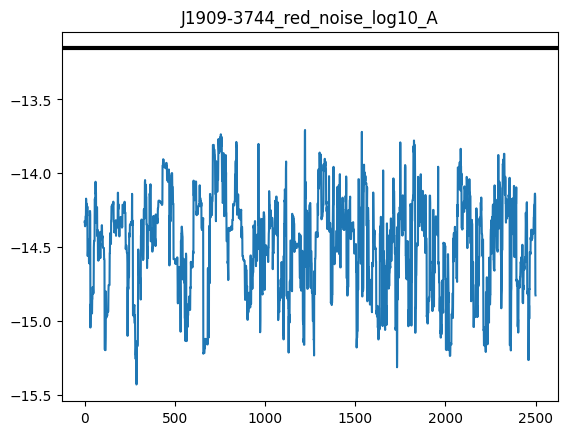

In [23]:
for i in range(len(pars)):
    plt.title(pars[i])
    plt.plot(ch[:,i])
    plt.axhline(p_inj[i], c='k', lw=3)
    plt.show()

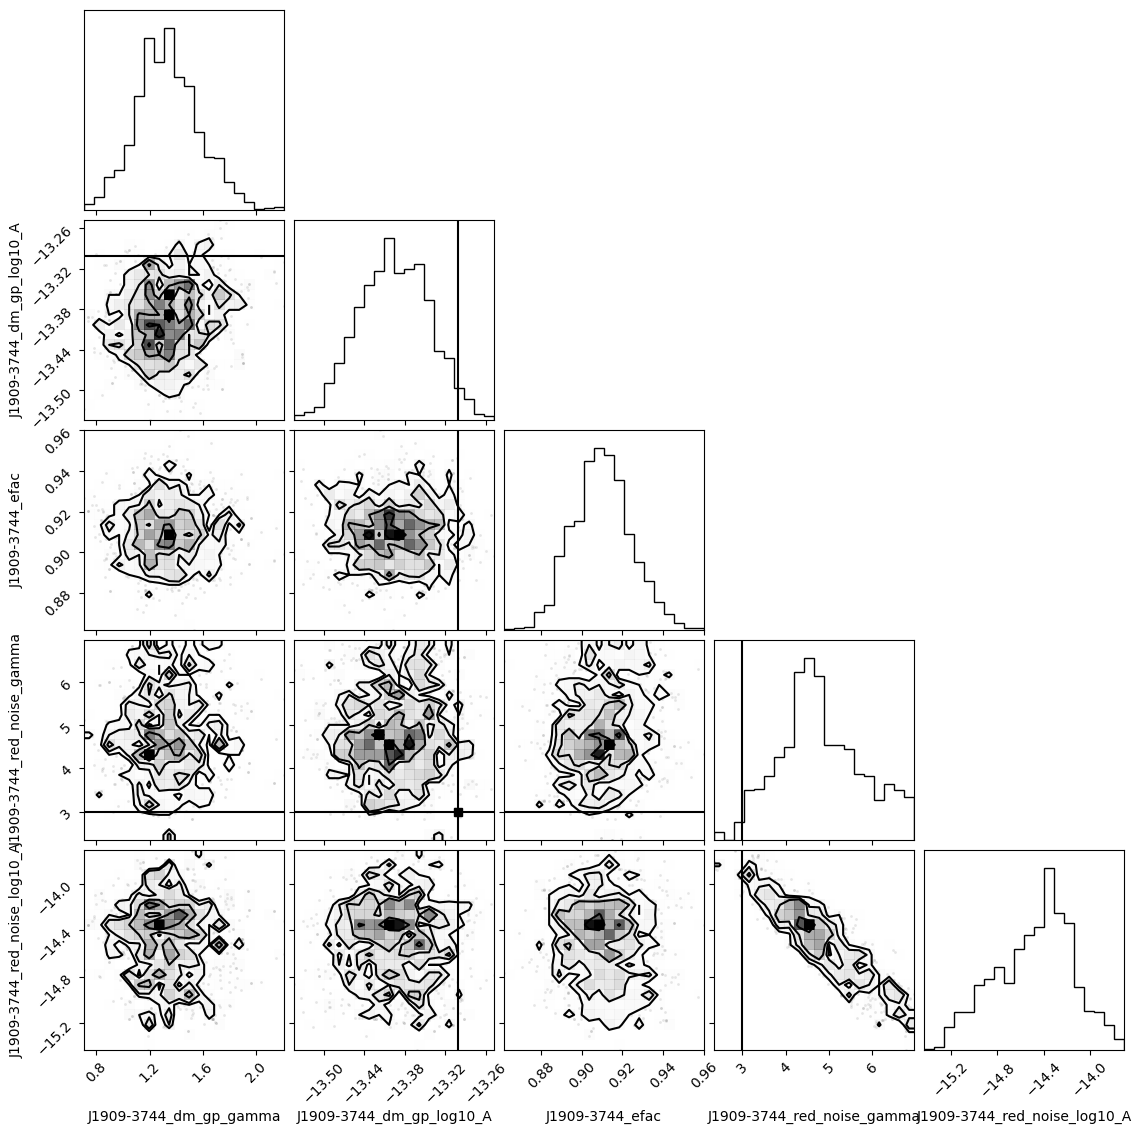

In [24]:
corner.corner(ch[::2,:-4], labels=pars, truths=p_inj, truth_color='k', hist_kwargs={"density":True})
plt.show()